# Notebook 2: Preprocessing & Feature Selection

**Input:** `patient_data.csv` (from Notebook 1)  
**Outputs:** `X_train.csv`, `X_test.csv`, `y_train.csv`, `y_test.csv` (sample -- for baseline models in NB3/NB4)  
**Also saves:** `X_train_full.csv`, `X_test_full.csv`, `y_train_full.csv`, `y_test_full.csv` (full dataset -- for final models in NB3/NB4)

---

## What this notebook does
1. Load `patient_data.csv`
2. Split the **full dataset** (40,336 patients) 80/20 into train and test
3. Fit the preprocessing pipeline (imputer, variance threshold, scaler) on the full training set
4. Run the RFE sweep on the **full training set** to find the best feature count k
5. Apply the final RFE to select features
6. Save the full-dataset train/test files (primary files for NB3/NB4)
7. Also create and save a stratified 5,000-patient sample for fast baseline exploration

---

**Data Leakage:**  
All preprocessing steps are **fit on the full training set only**, then applied to the test set. The test set is never seen during fitting of any transformer or during the RFE sweep.


## 1. Mount Google Drive

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 2. Configuration

In [2]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection   import train_test_split, StratifiedKFold, cross_val_score
from sklearn.feature_selection import VarianceThreshold, RFE
from sklearn.ensemble          import RandomForestClassifier
from sklearn.impute            import SimpleImputer
from sklearn.preprocessing     import StandardScaler
from sklearn.metrics           import f1_score

data_dir = Path('/content/drive/MyDrive/Colab Notebooks/Sepsis ML Project')

subset_size = 5000
random_seed = 42

plt.style.use('seaborn-v0_8-whitegrid')

## 3. Load Data

In [3]:
patient_df = pd.read_csv(data_dir / 'patient_data.csv', index_col='Patient_ID')
print(f'Loaded: {patient_df.shape[0]:,} patients, {patient_df.shape[1]} columns')

Loaded: 40,336 patients, 174 columns


## 4. Split Full Dataset & Fit Preprocessing Pipeline


### Split the full dataset and fit the preprocessing pipeline

We split all 40,336 patients 80/20 into train and test, then fit the preprocessing pipeline (imputer, variance threshold, scaler) on the **full training set**. This gives the transformers far more data to estimate medians, variances, and means from than fitting on a 5,000-patient sample.

The test set is only transformed (never fitted on), preserving data integrity.


In [4]:
# Split the full dataset (all 40,336 patients) into train and test
# This is the primary split -- the RFE sweep will run on this training set
x_full = patient_df.drop(columns=['Sepsis'])
y_full = patient_df['Sepsis']

x_train_f, x_test_f, y_train_f, y_test_f = train_test_split(
    x_full, y_full,
    test_size=0.2,
    stratify=y_full,
    random_state=random_seed
)

print(f'Full training set : {x_train_f.shape[0]:,} patients')
print(f'Full test set     : {x_test_f.shape[0]:,} patients')
print(f'Train sepsis rate : {y_train_f.mean()*100:.1f}%')
print(f'Test  sepsis rate : {y_test_f.mean()*100:.1f}%')


Full training set : 32,268 patients
Full test set     : 8,068 patients
Train sepsis rate : 7.3%
Test  sepsis rate : 7.3%


### Fit the preprocessing pipeline on the full training set

We fit the imputer, variance threshold, and scaler on the **full training set** (~32,000 patients). This gives the preprocessing steps far more data to estimate medians, variances, and means from -- producing more reliable transformations than fitting on only 4,000 patients.

The test set is only transformed (never fitted on).


In [5]:
# Step 1: drop zero-variance columns (computed from full training set)
zero_var_cols_f = x_train_f.columns[x_train_f.var() == 0].tolist()
x_train_f = x_train_f.drop(columns=zero_var_cols_f)
x_test_f  = x_test_f.drop(columns=zero_var_cols_f)
print(f'Zero-variance columns removed : {len(zero_var_cols_f)}')

# Step 2: drop >90% null columns (from full training set)
high_null_cols_f = x_train_f.columns[x_train_f.isnull().mean() > 0.90].tolist()
x_train_f = x_train_f.drop(columns=high_null_cols_f)
x_test_f  = x_test_f.drop(columns=high_null_cols_f)
print(f'High-null columns removed (>90%) : {len(high_null_cols_f)}')

# Step 3: impute -- fit on full training set
imputer_f = SimpleImputer(strategy='median')
x_train_f = pd.DataFrame(
    imputer_f.fit_transform(x_train_f),
    columns=x_train_f.columns, index=x_train_f.index
)
x_test_f = pd.DataFrame(
    imputer_f.transform(x_test_f),
    columns=x_test_f.columns, index=x_test_f.index
)
print(f'Nulls after imputation -- train: {x_train_f.isnull().sum().sum()}, test: {x_test_f.isnull().sum().sum()}')

# Step 4: VarianceThreshold -- fit on full training set
vt_f = VarianceThreshold(threshold=0.01)
vt_f.fit(x_train_f)
kept_cols_f = x_train_f.columns[vt_f.get_support()].tolist()
x_train_f = x_train_f[kept_cols_f]
x_test_f  = x_test_f[kept_cols_f]
print(f'After VarianceThreshold : {len(kept_cols_f)} features')

# Step 5: StandardScaler -- fit on full training set
scaler_f = StandardScaler()
x_train_f_scaled = pd.DataFrame(
    scaler_f.fit_transform(x_train_f),
    columns=kept_cols_f, index=x_train_f.index
)
x_test_f_scaled = pd.DataFrame(
    scaler_f.transform(x_test_f),
    columns=kept_cols_f, index=x_test_f.index
)
print(f'Scaling done. Full train shape: {x_train_f_scaled.shape}')


Zero-variance columns removed : 0
High-null columns removed (>90%) : 12
Nulls after imputation -- train: 0, test: 0
After VarianceThreshold : 156 features
Scaling done. Full train shape: (32268, 156)


### Step 6 -- RFE: Finding the Optimal Number of Features

Recursive Feature Elimination (RFE) works by:
1. Training a model on the current set of features
2. Ranking each feature by its importance score
3. Removing the least important feature
4. Repeating until `k` features remain

To find the best `k`, we sweep every integer from 1 to 20 (dense) then every 10 from 30 to 150 (coarse). For each `k`, a lightweight Random Forest selects the features and a slightly stronger one evaluates them using 5-fold CV F1 on the full training set only -- no test data involved.

**Result:** The sweep peaked at **k=50** (CV F1 = 0.5438). The F1 curve was noisy but generally higher in the k=4-17 range and again around k=50, then declined for larger k. This suggests a moderate number of features gives the best balance between signal and noise on this dataset.

**50 features selected:** A mix of absolute values (Temp_max, Lactate_min, Creatinine_max, PTT, WBC, Fibrinogen, Platelets, Bilirubin, Hgb), standard deviations (Hgb_std, Platelets_std), range features for all 34 vital/lab measurements, and ICULOS_max.


In [6]:
# RFE now runs on the full training set (x_train_f_scaled, ~32,000 patients).
# We use a denser sweep than the previous halving approach, which jumped from
# k=4 straight to k=9, potentially skipping the true optimum.
# Strategy: test every integer from 1 to 20 (dense), then every 10 beyond that (coarse).
n_f = x_train_f_scaled.shape[1]

feature_counts = list(range(1, 21)) + list(range(30, n_f + 1, 10))
feature_counts = sorted(set(feature_counts))

print(f"Features entering RFE : {n_f}")
print(f"k values to test      : {feature_counts}")


Features entering RFE : 156
k values to test      : [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 30, 40, 50, 60, 70, 80, 90, 100, 110, 120, 130, 140, 150]


In [7]:
# RFE sweep on the full training set.
# The internal estimator now has ~32,000 patients to rank features reliably.
# n_estimators=20 (up from 10) gives more stable importance rankings.
rfe_estimator = RandomForestClassifier(
    n_estimators=20, max_depth=5, class_weight="balanced", random_state=random_seed
)
f1_scores = []

for k in feature_counts:
    rfe = RFE(estimator=rfe_estimator, n_features_to_select=k, step=0.5)
    rfe.fit(x_train_f_scaled, y_train_f)

    x_tr_k = x_train_f_scaled.loc[:, rfe.support_]

    eval_model = RandomForestClassifier(
        n_estimators=50, max_depth=6, class_weight="balanced", random_state=random_seed
    )
    cv_scores = cross_val_score(
        eval_model, x_tr_k, y_train_f,
        cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=random_seed),
        scoring="f1"
    )
    f1 = cv_scores.mean()
    f1_scores.append(f1)
    print(f"  k = {k:3d}  ->  CV F1 = {f1:.4f}")

print()


  k =   1  ->  CV F1 = 0.4629
  k =   2  ->  CV F1 = 0.4920
  k =   3  ->  CV F1 = 0.4967
  k =   4  ->  CV F1 = 0.5323
  k =   5  ->  CV F1 = 0.5231
  k =   6  ->  CV F1 = 0.5134
  k =   7  ->  CV F1 = 0.5214
  k =   8  ->  CV F1 = 0.5007
  k =   9  ->  CV F1 = 0.5196
  k =  10  ->  CV F1 = 0.5054
  k =  11  ->  CV F1 = 0.5036
  k =  12  ->  CV F1 = 0.5075
  k =  13  ->  CV F1 = 0.4998
  k =  14  ->  CV F1 = 0.5010
  k =  15  ->  CV F1 = 0.5146
  k =  16  ->  CV F1 = 0.5233
  k =  17  ->  CV F1 = 0.5379
  k =  18  ->  CV F1 = 0.5239
  k =  19  ->  CV F1 = 0.5105
  k =  20  ->  CV F1 = 0.5025
  k =  30  ->  CV F1 = 0.5268
  k =  40  ->  CV F1 = 0.5229
  k =  50  ->  CV F1 = 0.5438
  k =  60  ->  CV F1 = 0.5329
  k =  70  ->  CV F1 = 0.5212
  k =  80  ->  CV F1 = 0.4953
  k =  90  ->  CV F1 = 0.5153
  k = 100  ->  CV F1 = 0.5005
  k = 110  ->  CV F1 = 0.5169
  k = 120  ->  CV F1 = 0.5155
  k = 130  ->  CV F1 = 0.4818
  k = 140  ->  CV F1 = 0.4783
  k = 150  ->  CV F1 = 0.4967



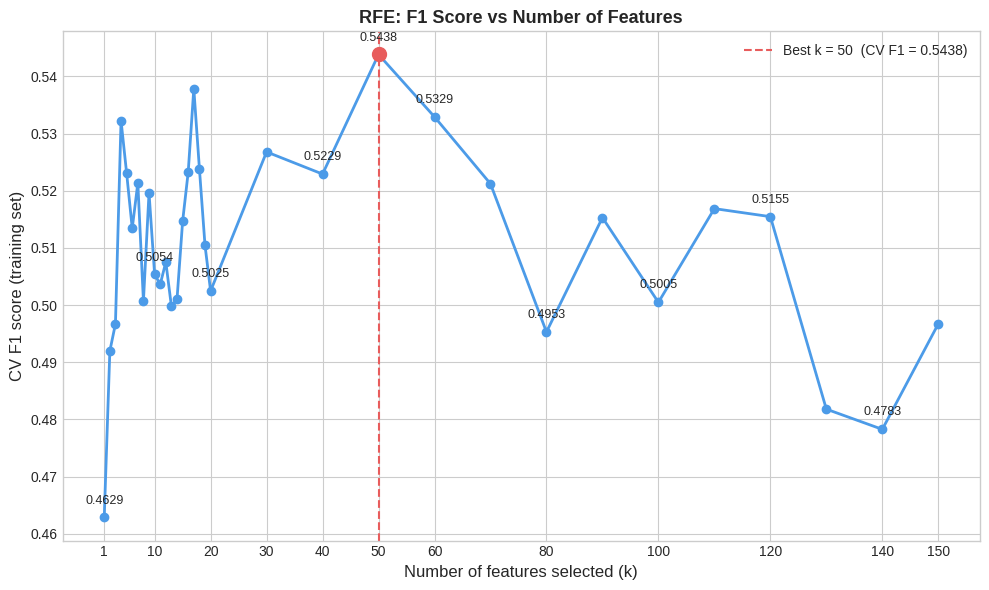

Best k = 50  (F1 = 0.5438)


In [9]:
# Find the index of the highest F1 score to determine the best 'k'
best_idx = int(np.argmax(f1_scores))
best_k   = feature_counts[best_idx]
best_f1  = f1_scores[best_idx]

# Set up the plot area
fig, ax = plt.subplots(figsize=(10, 6))

# Plot the F1 scores against the number of features
ax.plot(feature_counts, f1_scores, marker='o', linewidth=2, color='#4C9BE8', markersize=6)

# Add a vertical dashed line highlighting where the best 'k' is
ax.axvline(best_k, color='#E85C5C', linestyle='--', linewidth=1.5,
           label=f'Best k = {best_k}  (CV F1 = {best_f1:.4f})')

# Highlight the highest score point with a large red dot
ax.scatter([best_k], [best_f1], color='#E85C5C', zorder=5, s=100)

# Add text labels selectively to prevent crowding at the beginning
for k, f1 in zip(feature_counts, f1_scores):
    # Only annotate the best_k, k=1, k=10, and multiples of 20
    if k == best_k or k == 1 or k == 10 or k % 20 == 0:
        ax.annotate(f'{f1:.4f}', (k, f1), textcoords='offset points',
                    xytext=(0, 10), ha='center', fontsize=9)

# Add labels, title, and styling to make the plot look nice
ax.set_xlabel('Number of features selected (k)', fontsize=12)
ax.set_ylabel('CV F1 score (training set)', fontsize=12)
ax.set_title('RFE: F1 Score vs Number of Features', fontsize=13, fontweight='bold')

# Clean up x-axis ticks to avoid crowding
ax.set_xticks([1, 10, 20, 30, 40, 50, 60, 80, 100, 120, 140, 150])

ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

print(f'Best k = {best_k}  (F1 = {best_f1:.4f})')

### Final RFE

Run the final RFE with the best `k` to produce the definitive selected feature list. The value `n_features_selected = best_k` is set automatically from the plot cell. You can override it manually if you prefer a different point on the curve.


In [10]:
n_features_selected = best_k   # override here if needed

final_rfe = RFE(
    estimator=RandomForestClassifier(
        n_estimators=10, max_depth=4, class_weight='balanced', random_state=random_seed
    ),
    n_features_to_select=n_features_selected
)
final_rfe.fit(x_train_f_scaled, y_train_f)

selected_features = x_train_f_scaled.columns[final_rfe.support_].tolist()
print(f'Selected {len(selected_features)} features:')
for feat in selected_features:
    print(f'  {feat}')


Selected 50 features:
  Temp_max
  Creatinine_max
  Lactate_min
  Lactate_mean
  Bilirubin_total_min
  Bilirubin_total_max
  Hgb_mean
  Hgb_std
  PTT_min
  PTT_max
  PTT_mean
  WBC_max
  Fibrinogen_max
  Fibrinogen_mean
  Platelets_min
  Platelets_max
  Platelets_mean
  Platelets_std
  HR_range
  O2Sat_range
  Temp_range
  SBP_range
  MAP_range
  DBP_range
  Resp_range
  BaseExcess_range
  HCO3_range
  FiO2_range
  PaCO2_range
  SaO2_range
  AST_range
  BUN_range
  Alkalinephos_range
  Calcium_range
  Chloride_range
  Creatinine_range
  Glucose_range
  Lactate_range
  Magnesium_range
  Phosphate_range
  Potassium_range
  Bilirubin_total_range
  TroponinI_range
  Hct_range
  Hgb_range
  PTT_range
  WBC_range
  Fibrinogen_range
  Platelets_range
  ICULOS_max


In [11]:
# Apply final RFE feature selection to the full train/test sets
x_train_final_f = x_train_f_scaled[selected_features]
x_test_final_f  = x_test_f_scaled[selected_features]

print(f'Full train final shape : {x_train_final_f.shape}')
print(f'Full test  final shape : {x_test_final_f.shape}')


Full train final shape : (32268, 50)
Full test  final shape : (8068, 50)


## 6. Save Full-Dataset Files


In [12]:
# Save the full-dataset files (primary files for NB3/NB4)
x_train_final_f.to_csv(data_dir / 'X_train_full.csv')
x_test_final_f.to_csv(data_dir  / 'X_test_full.csv')
y_train_f.to_csv(data_dir       / 'y_train_full.csv')
y_test_f.to_csv(data_dir        / 'y_test_full.csv')

print(f'Full-dataset files saved to {data_dir}')
print(f'  X_train_full.csv : {x_train_final_f.shape[0]:,} patients x {x_train_final_f.shape[1]} features')
print(f'  X_test_full.csv  : {x_test_final_f.shape[0]:,} patients x {x_test_final_f.shape[1]} features')
print(f'  y_train_full.csv : {y_train_f.shape[0]:,} labels')
print(f'  y_test_full.csv  : {y_test_f.shape[0]:,} labels')


Full-dataset files saved to /content/drive/MyDrive/Colab Notebooks/Sepsis ML Project
  X_train_full.csv : 32,268 patients x 50 features
  X_test_full.csv  : 8,068 patients x 50 features
  y_train_full.csv : 32,268 labels
  y_test_full.csv  : 8,068 labels


## 7. Feature Reduction Summary


In [ ]:
print('FEATURE REDUCTION SUMMARY (full dataset)')
print()
print(f'After aggregation         : {len(patient_df.columns) - 1}')
print(f'After zero-variance       : {len(patient_df.columns) - 1 - len(zero_var_cols_f)}')
print(f'After >90% null removal   : {len(patient_df.columns) - 1 - len(zero_var_cols_f) - len(high_null_cols_f)}')
print(f'After VarianceThreshold   : {len(kept_cols_f)}')
print(f"After RFE (k={n_features_selected})".ljust(26) + f": {n_features_selected}")
print()
print(f'Full train : {x_train_final_f.shape[0]:,} patients x {x_train_final_f.shape[1]} features')
print(f'Full test  : {x_test_final_f.shape[0]:,} patients x {x_test_final_f.shape[1]} features')
print()
print('Also saving 5,000-patient sample for baseline models...')


---

## 8. Create 5,000-Patient Sample (for baseline models)

The full-dataset files above are the primary files used by Notebooks 3 and 4 for the tuned models. We also create a small 5,000-patient stratified sample using the same preprocessing pipeline (same fitted imputer, scaler, variance threshold, and selected features). This sample is used only for baseline (untuned) model comparisons.


**Note on the sample preprocessing:**  
The sample is preprocessed using the exact same fitted objects (imputer, scaler, variance threshold) as the full dataset, and the same `selected_features` list from RFE. This ensures the sample and full-dataset files are perfectly comparable.


In [14]:
# Create a 5,000-patient stratified sample from the full dataset
# This is used ONLY for the baseline (untuned) models in NB3/NB4
# to show what performance looks like with less data
_, subset_df = train_test_split(
    patient_df,
    test_size=subset_size,
    stratify=patient_df['Sepsis'],
    random_state=random_seed
)

x_s = subset_df.drop(columns=['Sepsis'])
y_s = subset_df['Sepsis']

x_train_s, x_test_s, y_train_s, y_test_s = train_test_split(
    x_s, y_s, test_size=0.2, stratify=y_s, random_state=random_seed
)

# Preprocess sample using the SAME fitted objects from the full pipeline
x_train_s = x_train_s.drop(columns=zero_var_cols_f + high_null_cols_f, errors='ignore')
x_test_s  = x_test_s.drop(columns=zero_var_cols_f + high_null_cols_f,  errors='ignore')

x_train_s = pd.DataFrame(imputer_f.transform(x_train_s),
    columns=x_train_s.columns, index=x_train_s.index)
x_test_s  = pd.DataFrame(imputer_f.transform(x_test_s),
    columns=x_test_s.columns,  index=x_test_s.index)

x_train_s = x_train_s[kept_cols_f]
x_test_s  = x_test_s[kept_cols_f]

x_train_s = pd.DataFrame(scaler_f.transform(x_train_s),
    columns=kept_cols_f, index=x_train_s.index)
x_test_s  = pd.DataFrame(scaler_f.transform(x_test_s),
    columns=kept_cols_f, index=x_test_s.index)

x_train_s = x_train_s[selected_features]
x_test_s  = x_test_s[selected_features]

# Save sample files
x_train_s.to_csv(data_dir / 'X_train.csv')
x_test_s.to_csv(data_dir  / 'X_test.csv')
y_train_s.to_csv(data_dir / 'y_train.csv')
y_test_s.to_csv(data_dir  / 'y_test.csv')

print(f'Sample files saved (5,000-patient subset):')
print(f'  X_train.csv : {x_train_s.shape[0]} patients x {x_train_s.shape[1]} features')
print(f'  X_test.csv  : {x_test_s.shape[0]} patients x {x_test_s.shape[1]} features')
print()
print('Next: run 03_random_forest.ipynb')


Sample files saved (5,000-patient subset):
  X_train.csv : 4000 patients x 50 features
  X_test.csv  : 1000 patients x 50 features

Next: run 03_random_forest.ipynb
